# As escolas de Uberlândia (Censo Escolar 2025)

Quantas escolas a cidade tem, de quais redes, quantos alunos estudam nelas e quem são esses alunos. Fonte: microdados do Censo Escolar 2025 do INEP, filtrados para o município de Uberlândia (código 3170206).

## Preparando os dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def br(x):
    return f"{x:,.0f}".replace(",", ".")

rede = pd.read_csv("dados/escolas_matriculas_por_rede.csv", index_col=0)
etapa = pd.read_csv("dados/matriculas_por_etapa.csv")
cor = pd.read_csv("dados/matriculas_por_cor_raca.csv")
idade = pd.read_csv("dados/matriculas_por_idade.csv")
rede

,escolas,matriculas,alunos_por_escola
rede,,,
Estadual,69,52014,754
Federal,4,2213,553
Municipal,123,60179,489
Privada,172,42049,244


## Quantas escolas, quantos alunos

Uberlândia tem 368 escolas em atividade e 156.455 matrículas na educação básica (2025). Mas a distribuição entre as redes surpreende: a rede privada tem quase metade das escolas (172) e só 27% das matrículas.

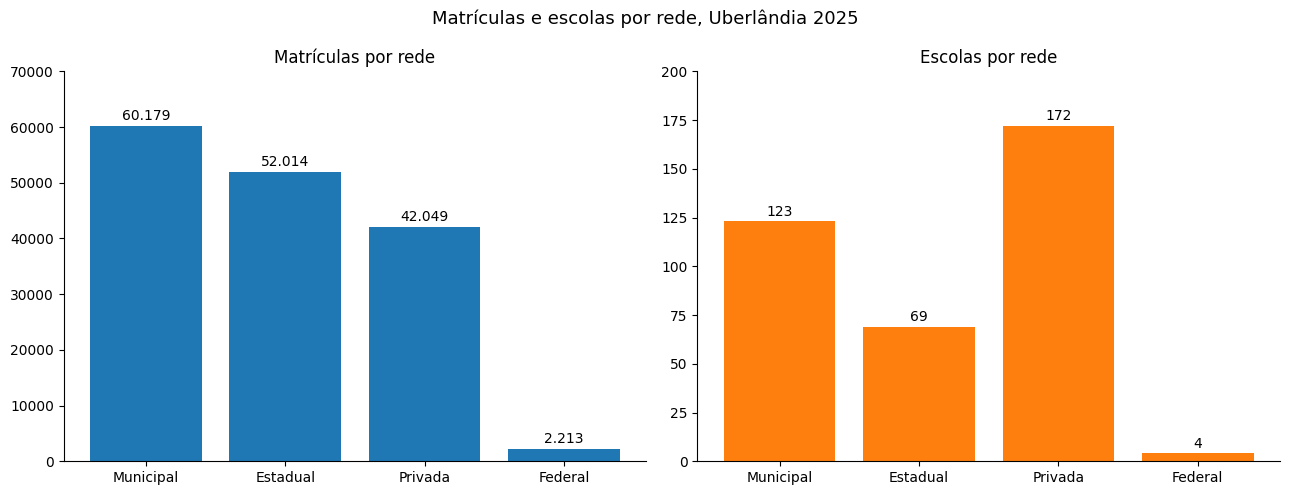

In [2]:
ordem = rede.sort_values("matriculas", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
b1 = axes[0].bar(ordem.index, ordem["matriculas"], color="#1f77b4")
axes[0].set_title("Matrículas por rede")
for b in b1:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 1000, br(b.get_height()), ha="center", fontsize=10)
axes[0].set_ylim(0, 70000)
b2 = axes[1].bar(ordem.index, ordem["escolas"], color="#ff7f0e")
axes[1].set_title("Escolas por rede")
for b in b2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 3, br(b.get_height()), ha="center", fontsize=10)
axes[1].set_ylim(0, 200)
fig.suptitle("Matrículas e escolas por rede, Uberlândia 2025", fontsize=13)
plt.tight_layout()
plt.savefig("grafico_rede.png", dpi=150)
plt.show()

O tamanho médio das escolas mostra bem a diferença: cada escola estadual tem em média 754 alunos, cada municipal 489, e cada privada 244. As quatro federais (IFTM e CEFET/Coltec, por exemplo) ficam com 553 por unidade.

## Em que etapa os alunos estão

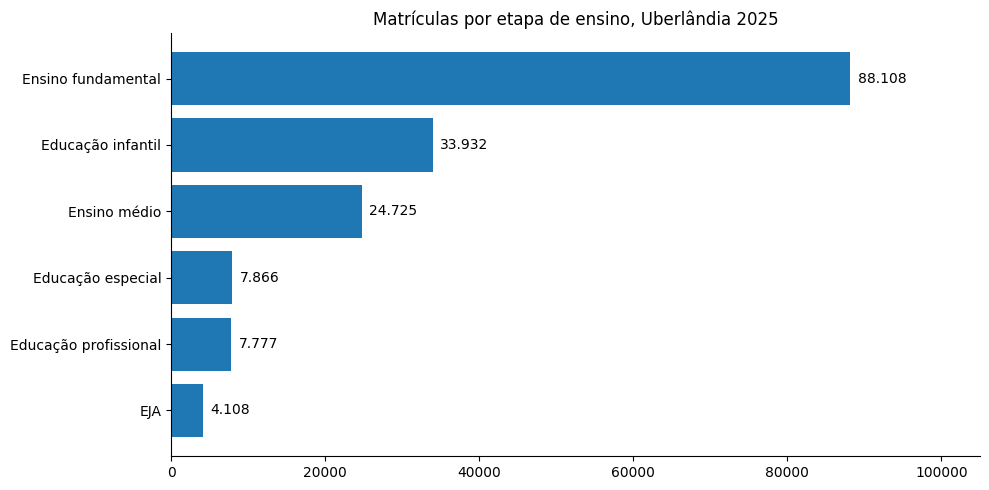

In [3]:
et = etapa.sort_values("matriculas")
fig, ax = plt.subplots()
bars = ax.barh(et["etapa"], et["matriculas"], color="#1f77b4")
for b, v in zip(bars, et["matriculas"]):
    ax.text(v + 1000, b.get_y() + b.get_height()/2, br(v), va="center", fontsize=10)
ax.set_xlim(0, 105000)
ax.set_title("Matrículas por etapa de ensino, Uberlândia 2025")
plt.tight_layout()
plt.savefig("grafico_etapas.png", dpi=150)
plt.show()

O ensino fundamental concentra 88.108 matrículas, mais que a metade do total. A soma das etapas passa do total de matrículas porque uma mesma matrícula pode contar em mais de uma etapa (educação profissional e educação especial, por exemplo, se somam ao médio e ao fundamental). Por isso este gráfico mostra o tamanho de cada etapa, não uma divisão do bolo.

## Quem são os alunos

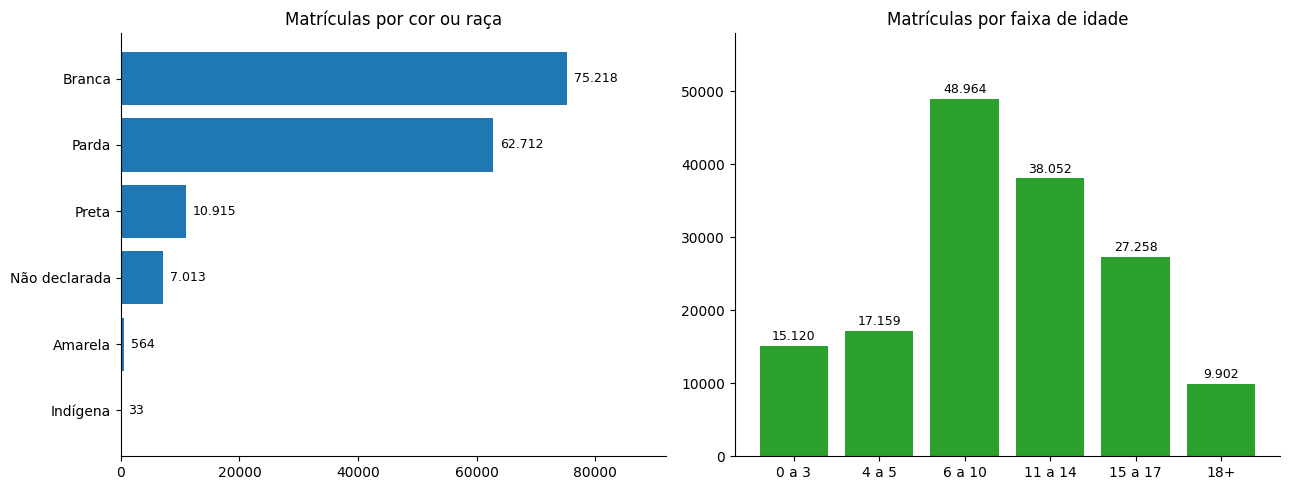

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
c = cor.sort_values("matriculas")
bars = axes[0].barh(c["cor_raca"], c["matriculas"], color="#1f77b4")
for b, v in zip(bars, c["matriculas"]):
    axes[0].text(v + 1200, b.get_y() + b.get_height()/2, br(v), va="center", fontsize=9)
axes[0].set_title("Matrículas por cor ou raça")
axes[0].set_xlim(0, 92000)
i = idade
bars = axes[1].bar(i["faixa_idade"], i["matriculas"], color="#2ca02c")
for b, v in zip(bars, i["matriculas"]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 800, br(v), ha="center", fontsize=9)
axes[1].set_title("Matrículas por faixa de idade")
axes[1].set_ylim(0, 58000)
plt.tight_layout()
plt.savefig("grafico_perfil.png", dpi=150)
plt.show()

Metade das matrículas é de alunos pretos ou pardos (48% contra 45% de brancos; o restante não declarou). Pela idade, o grosso está entre 6 e 14 anos, idade típica do fundamental. Os 9.902 alunos com 18 anos ou mais mostram o peso da EJA e de quem retomou os estudos.

Na divisão por sexo, é praticamente meio a meio: 50,5% meninos e 49,5% meninas.

## Ressalvas

- O Censo Escolar é declaratório: os números vêm do que cada escola informou ao INEP em 2025.
- Cor ou raça tem 7.013 matrículas sem declaração, por isso os percentuais não fecham 100%.
- Escolas rurais são só 20 das 368; a análise é quase toda urbana.

## Fontes

- INEP, microdados do Censo Escolar da Educação Básica 2025 (https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-escolar), filtrados para Uberlândia (CO_MUNICIPIO 3170206). Somente escolas em atividade.
- Conferência independente: os totais batem com o painel escolasbrasil.org, que usa a mesma base (368 escolas, 156.455 matrículas).

Os CSVs em `dados/` têm os valores de cada gráfico.